# AI Quantum 2026 — DRL Model Engine Pipeline Notebook

Notebook này minh họa quy trình hoạt động hoàn chỉnh của **Model Engine**:
1. **Lấy dữ liệu + In ra bảng**: Truy vấn dữ liệu OHLCV & chỉ báo kỹ thuật từ Database/DuckDB cho các tập **Train**, **Validation**, và **Test Set (Out-of-Sample)** với lịch sử nung nóng (Lookback Warm-up), làm sạch dữ liệu qua  và hiển thị bảng thông số.
2. **Train model**: Khởi tạo môi trường giao dịch , huấn luyện mô hình DRL () từ cấu hình  (), sau đó **kiểm thử out-of-sample trên tập TEST SET**.
3. **Trực quan kết quả**: Đánh giá hiệu năng danh mục trên **Tập TEST SET**, tính toán các chỉ số tài chính (Sharpe, Sortino, Max Drawdown) và trực quan hóa kết quả qua .

In [1]:
import os
import sys
import pandas as pd
import numpy as np

# Tự động tích hợp IPython display nếu chạy ngoài môi trường notebook
try:
    from IPython.display import display, Image
except ImportError:
    display = print

# Thiết lập sys.path để import các module từ pipeline và root
notebook_dir = os.path.dirname(os.path.abspath("__file__")) if "__file__" in locals() else os.getcwd()
pipeline_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
project_root = os.path.abspath(os.path.join(notebook_dir, "../../.."))

for p in [pipeline_dir, project_root]:
    if p not in sys.path:
        sys.path.insert(0, p)

from model_engine.data.data_service import DataQueryService
from model_engine.data.processor import DataProcessor
from model_engine.env.stock_trading_env import StockTradingEnv
from model_engine.models.drl_models import DRLEnsembleStrategy
from model_engine.analysis.visualization import ModelVisualizer
from core.config.settings import MODEL_CONFIG, settings
from core.utils.seed_manager import set_global_seed

# Guard assertion for configuration integrity
required_keys = ['train_start_date', 'val_start_date', 'test_start_date', 'features', 'initial_balance']
for key in required_keys:
    assert key in MODEL_CONFIG and MODEL_CONFIG[key], f"❌ Config key '{key}' missing or empty in model.yaml!"

print("✅ Khởi tạo hệ thống và kiểm tra cấu hình thành công!")

✅ Khởi tạo hệ thống và kiểm tra cấu hình thành công!


## 1. Lấy dữ liệu + In ra bảng

In [2]:
# 1. Khởi tạo DataQueryService
data_service = DataQueryService()

# 2. Truy vấn khoảng thời gian Train, Validation và Test trực tiếp từ MODEL_CONFIG (config/model.yaml)
train_start = MODEL_CONFIG.get("train_start_date", "2018-08-06")
train_end = MODEL_CONFIG.get("train_end_date", "2022-12-31")
val_start = MODEL_CONFIG.get("val_start_date", "2023-01-01")
val_end = MODEL_CONFIG.get("val_end_date", "2023-12-31")
test_start = MODEL_CONFIG.get("test_start_date", "2024-01-01")
test_end = MODEL_CONFIG.get("test_end_date", "2024-12-31")

print(f"📥 Đang lấy dữ liệu Train ({train_start} -> {train_end}) kèm lịch sử nung nóng...")
raw_train_df = data_service.fetch_data(train_start, train_end, lookback_days=45)

print(f"📥 Đang lấy dữ liệu Validation ({val_start} -> {val_end}) kèm lịch sử nung nóng...")
raw_val_df = data_service.fetch_data(val_start, val_end, lookback_days=45)

print(f"📥 Đang lấy dữ liệu Test ({test_start} -> {test_end}) kèm lịch sử nung nóng...")
raw_test_df = data_service.fetch_data(test_start, test_end, lookback_days=45)

print(f"📥 Đang lấy dữ liệu Benchmark VN30 giai đoạn Test ({test_start} -> {test_end})...")
bm_test_df = data_service.fetch_symbol_data("VN30", test_start, test_end)

# 3. Tiền xử lý dữ liệu với DataProcessor (Z-Score chuẩn hóa và tự động lọc bỏ phần warm-up)
features = MODEL_CONFIG.get("features", ["RSI", "PPO", "CCI", "ADX", "ATR", "VOLATILITY", "YIELD_CURVE_SLOPE", "DXY_LOG_RETURN", "VN3YT"])

train_df = DataProcessor(raw_train_df, features).clean_data(start_date=train_start)
val_df = DataProcessor(raw_val_df, features).clean_data(start_date=val_start)
test_df = DataProcessor(raw_test_df, features).clean_data(start_date=test_start)

# 4. In ra bảng thông số dữ liệu tổng quan
summary_info = {
    "Tập dữ liệu": ["Train Set", "Validation Set", "Test Set (Out-of-Sample)", "Benchmark VN30 (Test)"],
    "Số dòng": [len(train_df), len(val_df), len(test_df), len(bm_test_df)],
    "Từ ngày": [train_start, val_start, test_start, test_start],
    "Đến ngày": [train_end, val_end, test_end, test_end],
    "Số Tickers": [
        train_df["tic"].nunique() if "tic" in train_df.columns else 0,
        val_df["tic"].nunique() if "tic" in val_df.columns else 0,
        test_df["tic"].nunique() if "tic" in test_df.columns else 0,
        bm_test_df["tic"].nunique() if not bm_test_df.empty and "tic" in bm_test_df.columns else 1
    ]
}
summary_df = pd.DataFrame(summary_info)

print("\n📊 TỔNG QUAN CÁC BỘ DỮ LIỆU SAU KHI NUNG NÓNG VÀ LỌC LỊCH SỬ:")
display(summary_df)

print("\n🔍 PREVIEW 10 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU TRAIN (TỪ NGÀY BẮT ĐẦU CHÍNH THỨC):")
display(train_df.head(10))

📥 Đang lấy dữ liệu Train (2018-01-01 -> 2022-12-31) kèm lịch sử nung nóng...
📥 Đang lấy dữ liệu Validation (2023-01-01 -> 2023-12-31) kèm lịch sử nung nóng...
📥 Đang lấy dữ liệu Test (2024-01-01 -> 2024-12-31) kèm lịch sử nung nóng...
📥 Đang lấy dữ liệu Benchmark VN30 giai đoạn Test (2024-01-01 -> 2024-12-31)...

📊 TỔNG QUAN CÁC BỘ DỮ LIỆU SAU KHI NUNG NÓNG VÀ LỌC LỊCH SỬ:


,Tập dữ liệu,Số dòng,Từ ngày,Đến ngày,Số Tickers
0,Train Set,6158,2018-01-01,2022-12-31,5
1,Validation Set,1245,2023-01-01,2023-12-31,5
2,Test Set (Out-of-Sample),1250,2024-01-01,2024-12-31,5
3,Benchmark VN30 (Test),250,2024-01-01,2024-12-31,1



🔍 PREVIEW 10 DÒNG ĐẦU TIÊN CỦA BỘ DỮ LIỆU TRAIN (TỪ NGÀY BẮT ĐẦU CHÍNH THỨC):


,tic,date,open,high,low,close,volume,TURBULENCE,RSI,PPO,CCI,ADX,ATR,VOLATILITY,YIELD_CURVE_SLOPE,DXY_LOG_RETURN,VN3YT
0,FPT,2018-01-02,14790.0,15440.0,14760.0,15440.0,5022160.0,14.029577,0.759861,-0.619996,1.661901,-1.724382,-1.169166,-0.122856,3.0,-3.0,3.000000
1,HPG,2018-01-02,7950.0,8090.0,7870.0,8080.0,4105100.0,14.029577,1.763992,1.879103,0.375255,2.170038,1.348431,-1.370469,3.0,-3.0,3.000000
2,VCB,2018-01-02,22640.0,23230.0,22460.0,23060.0,2801720.0,14.029577,0.911916,1.176925,0.479740,-1.106601,1.125749,0.947464,3.0,-3.0,3.000000
3,VNM,2018-01-02,97570.0,97980.0,96470.0,97790.0,372760.0,14.029577,0.160238,-1.101286,1.134154,-1.393501,-0.177164,-1.895883,3.0,-3.0,3.000000
4,FPT,2018-01-03,15610.0,15650.0,15360.0,15440.0,2829930.0,0.565583,0.799827,-0.390605,1.893480,-1.529780,-1.332687,-0.246755,3.0,3.0,3.000000
5,HPG,2018-01-03,8140.0,8220.0,8010.0,8060.0,4828220.0,0.565583,1.533899,1.856753,0.333955,2.458604,1.334944,-1.292523,3.0,3.0,3.000000
6,VCB,2018-01-03,23270.0,23360.0,22840.0,23020.0,1843870.0,0.565583,0.859119,1.204393,0.406221,-0.980724,0.952710,0.884833,3.0,3.0,3.000000
7,VNM,2018-01-03,98740.0,99410.0,98070.0,98900.0,557370.0,0.565583,0.478354,-0.906859,1.603545,-1.196157,-0.412713,-2.140087,3.0,3.0,3.000000
8,FPT,2018-01-04,15480.0,15740.0,15460.0,15740.0,2784800.0,1.494447,1.214863,-0.096279,1.716528,-1.350790,-1.438242,-0.243333,3.0,-3.0,2.890582
9,HPG,2018-01-04,8100.0,8200.0,8060.0,8160.0,4640280.0,1.494447,1.601854,1.855365,0.197100,2.577462,1.079431,-1.429557,3.0,-3.0,2.890582


## 2. Train model

In [3]:
# 1. Cấu hình tham số môi trường StockTradingEnv trực tiếp từ MODEL_CONFIG
reward_cfg = MODEL_CONFIG.get("reward_settings", {})
turb_cfg = MODEL_CONFIG.get("turbulence_settings", {})
raw_trig = turb_cfg.get("threshold_trigger")
raw_thresh = turb_cfg.get("threshold")
if raw_trig is not None:
    turb_threshold = float(raw_trig)
elif raw_thresh is not None:
    turb_threshold = float(raw_thresh)
else:
    turb_threshold = 100.0

initial_balance = float(MODEL_CONFIG.get("initial_balance", 1_000_000_000.0))

env_kwargs = {
    "features": features,
    "initial_balance": initial_balance,
    "turbulence_threshold": turb_threshold,
    "reward_settings": reward_cfg,
    "turbulence_settings": turb_cfg,
}

# 2. Đọc các thông số huấn luyện trực tiếp từ file config (config/model.yaml)
training_settings = MODEL_CONFIG.get("training_settings", {})
total_timesteps = int(training_settings.get("total_timesteps", 50000))

print(f"⚙️ Cấu hình huấn luyện từ config/model.yaml:")
print(f"   - Total Timesteps: {total_timesteps:,}")
print(f"   - Algorithm: PPO")
print(f"   - Reward Function: {reward_cfg.get('reward_type', 'drawdown_penalty')}")
print(f"   - Turbulence Type: {turb_cfg.get('turbulence_type', 'dual_threshold')}")
print(f"   - Features ({len(features)}): {features}")

ensemble_strategy = DRLEnsembleStrategy(
    env_train_class=StockTradingEnv,
    env_kwargs=env_kwargs,
    train_data=train_df,
    val_data=val_df,
    total_timesteps=total_timesteps
)

# 3. Synchronize global seed & train PPO model
seed = int(MODEL_CONFIG.get("training_settings", {}).get("random_seed", 42))
set_global_seed(seed)

print()
print("🚀 Đang tiến hành huấn luyện mô hình PPO trên Train Set...")
best_algo_name = "PPO"
best_model = ensemble_strategy.train_ppo()

print()
print(f"🏆 Đã hoàn thành huấn luyện mô hình: {best_algo_name}")

# 4. Đánh giá kiểm thử Out-of-Sample của mô hình trên tập TEST SET ({test_start} đến {test_end})
print()
print(f"🧪 Tiến hành kiểm thử Out-of-Sample mô hình {best_algo_name} trên tập TEST SET ({test_start} -> {test_end})...")
df_account, df_actions, df_shares = ensemble_strategy.evaluate_and_get_trajectory(best_model, test_df)

print()
print("📈 BẢNG LỊCH SỬ TÀI KHOẢN (ACCOUNT VALUE) TRÊN TẬP TEST SET (10 DÒNG ĐẦU):")
display(df_account.tail(10))

⚙️ Cấu hình huấn luyện từ config/model.yaml:
   - Total Timesteps: 50,000
   - Algorithm: PPO
   - Reward Function: sortino
   - Turbulence Type: dual_threshold
   - Features (9): ['RSI', 'PPO', 'CCI', 'ADX', 'ATR', 'VOLATILITY', 'YIELD_CURVE_SLOPE', 'DXY_LOG_RETURN', 'VN3YT']

🚀 Đang tiến hành huấn luyện mô hình PPO trên Train Set...

🏆 Đã hoàn thành huấn luyện mô hình: PPO

🧪 Tiến hành kiểm thử Out-of-Sample mô hình PPO trên tập TEST SET (2024-01-01 -> 2024-12-31)...

📈 BẢNG LỊCH SỬ TÀI KHOẢN (ACCOUNT VALUE) TRÊN TẬP TEST SET (10 DÒNG ĐẦU):


,date,account_value,daily_return
239,2024-12-17,1.052264e+09,0.003467
240,2024-12-18,1.050693e+09,-0.001493
241,2024-12-19,1.051573e+09,0.000837
242,2024-12-20,1.041166e+09,-0.009897
243,2024-12-23,1.046256e+09,0.004889
244,2024-12-24,1.047710e+09,0.001390
245,2024-12-25,1.044737e+09,-0.002838
246,2024-12-26,1.049535e+09,0.004592
247,2024-12-27,1.046881e+09,-0.002529
248,2024-12-30,1.044526e+09,-0.002249


## 3. Trực quan kết quả

🎨 Đang vẽ biểu đồ trực quan hóa kết quả kiểm thử trên TEST SET...

📋 BẢNG CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST SET (OUT-OF-SAMPLE):


/Users/khanhba89/Documents/NEU/ai_quantum_2026/src/pipeline/model_engine/analysis/visualization.py:300: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans Mono.
  fig.savefig(save_path, bbox_inches="tight")


,Chỉ số Hiệu năng (Test Set),Giá trị
0,Lợi nhuận tích lũy (Cumulative Return),4.45%
1,Lợi nhuận quy năm (Annualized Return),4.51%
2,Biến động quy năm (Annualized Volatility),9.88%
3,Tỷ lệ Sharpe (Sharpe Ratio),0.15
4,Tỷ lệ Sortino (Sortino Ratio),0.22
5,Mức sụt giảm tối đa (Max Drawdown),-6.53%
6,Tỷ lệ Calmar (Calmar Ratio),0.69
7,Tỷ lệ Thắng (Win Rate),49.58%



🖼️ BIỂU ĐỒ TEST SET EVALUATION DASHBOARD (Lưu tại: /Users/khanhba89/Documents/NEU/ai_quantum_2026/data/reports/notebook_test_summary_dashboard.png):


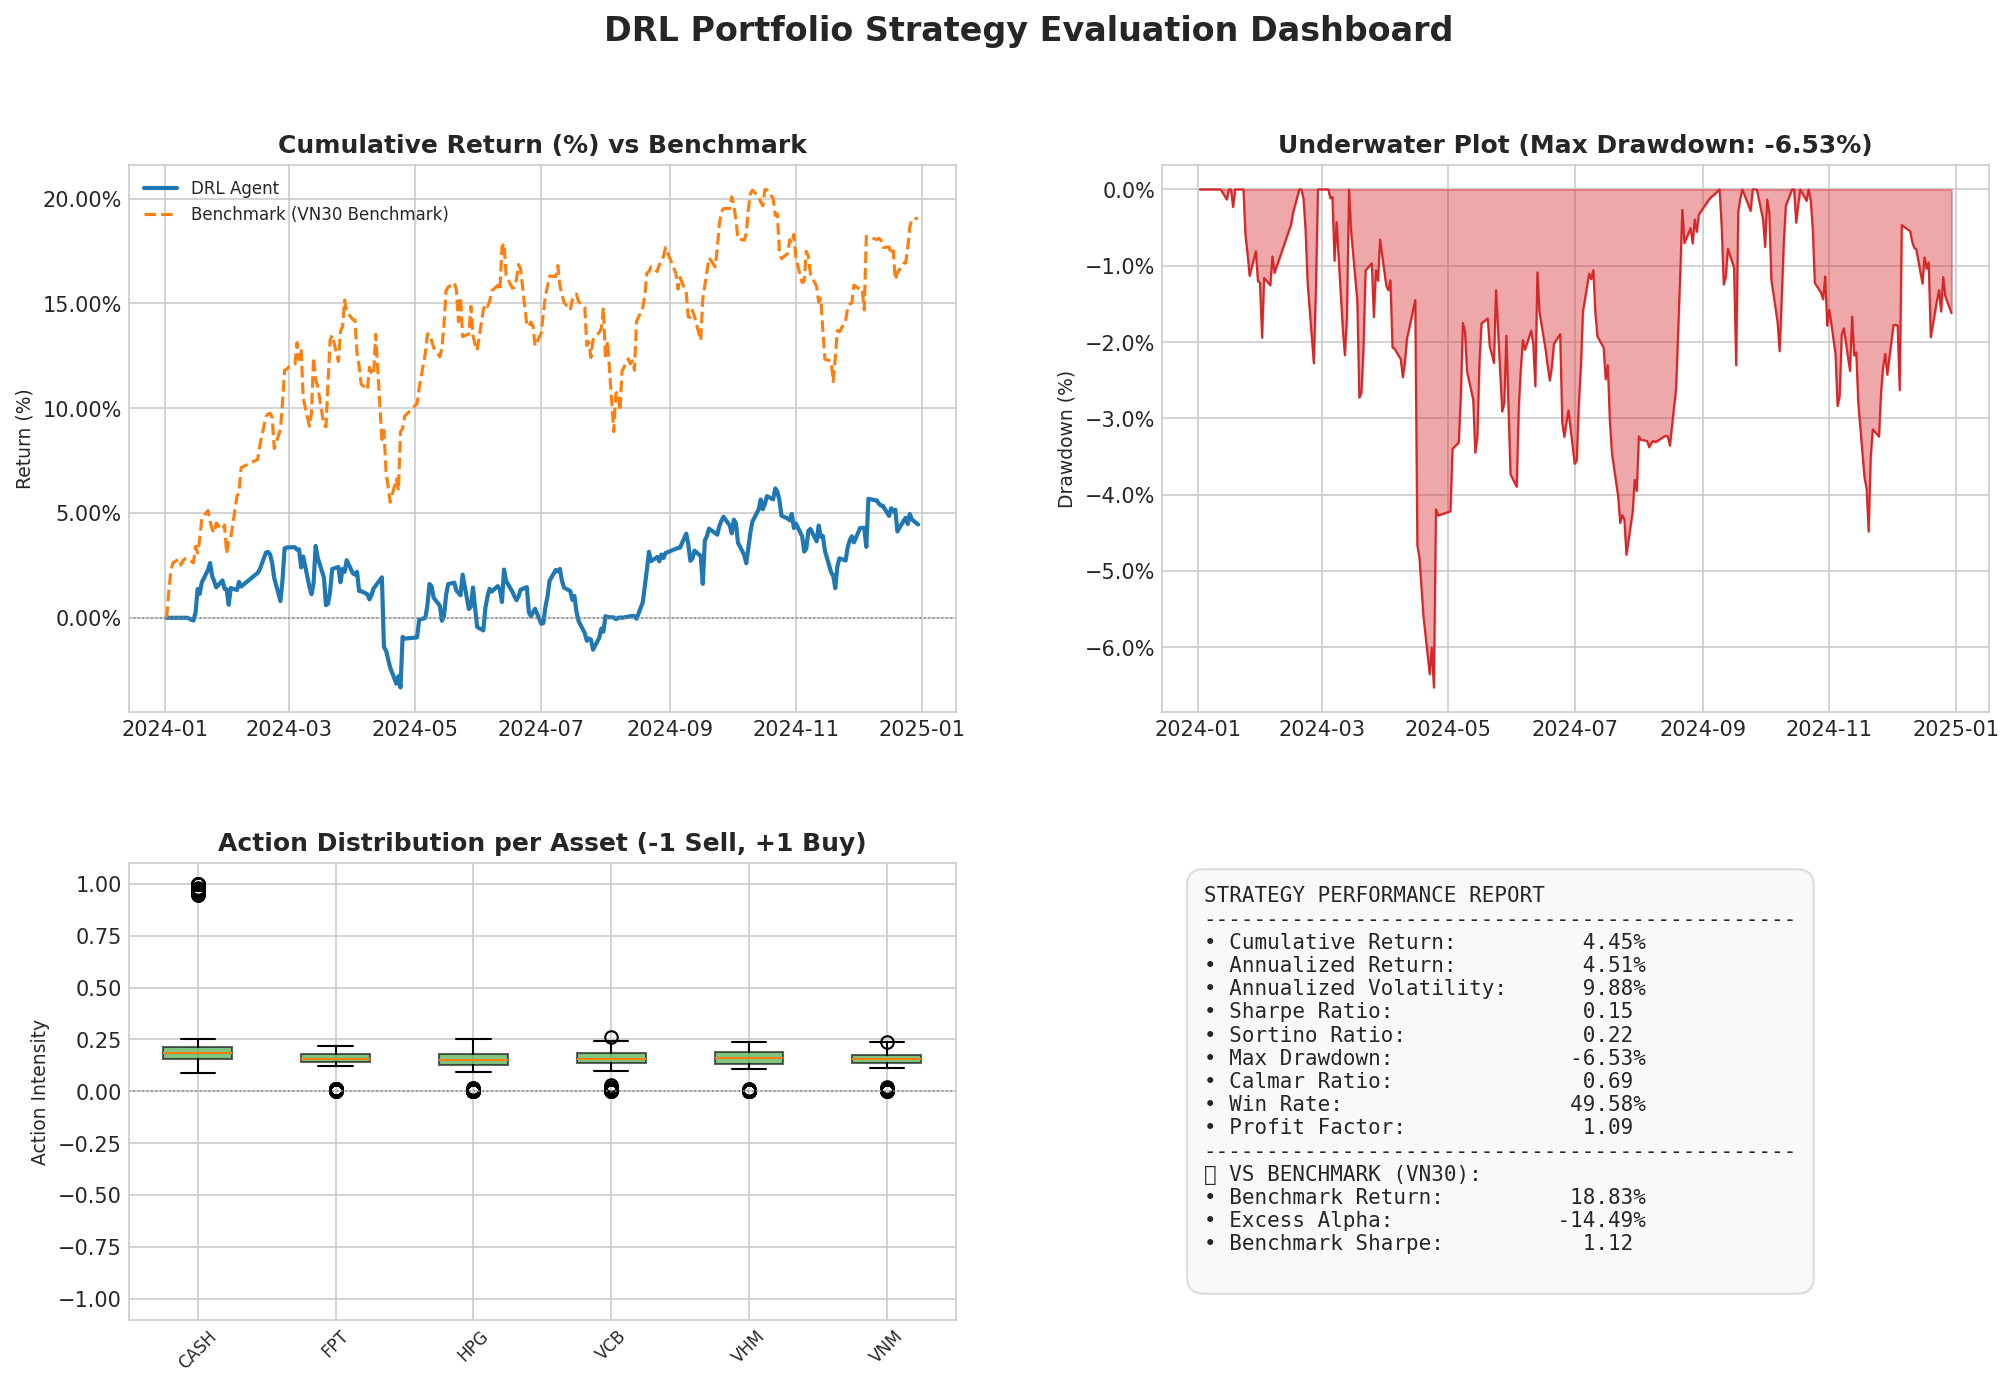

In [4]:
# 1. Khởi tạo ModelVisualizer xuất báo cáo ra thư mục data/reports
reports_dir = os.path.abspath(os.path.join(project_root, "data", "reports"))
visualizer = ModelVisualizer(output_dir=reports_dir)

# 2. Trực quan hóa và xuất Summary Dashboard 2x2 cho tập TEST SET
print("🎨 Đang vẽ biểu đồ trực quan hóa kết quả kiểm thử trên TEST SET...")
dashboard_path, metrics = visualizer.plot_summary_dashboard(
    df_agent=df_account,
    df_actions=df_actions,
    df_benchmark=bm_test_df,
    benchmark_name="VN30 Benchmark",
    save_name="notebook_test_summary_dashboard.png"
)

# 3. Hiển thị bảng chỉ số đo lường hiệu năng Out-of-Sample trên tập TEST SET
metrics_data = [
    {"Chỉ số Hiệu năng (Test Set)": "Lợi nhuận tích lũy (Cumulative Return)", "Giá trị": f"{metrics.get('cumulative_return', 0)*100:.2f}%"},
    {"Chỉ số Hiệu năng (Test Set)": "Lợi nhuận quy năm (Annualized Return)", "Giá trị": f"{metrics.get('annualized_return', 0)*100:.2f}%"},
    {"Chỉ số Hiệu năng (Test Set)": "Biến động quy năm (Annualized Volatility)", "Giá trị": f"{metrics.get('annualized_volatility', 0)*100:.2f}%"},
    {"Chỉ số Hiệu năng (Test Set)": "Tỷ lệ Sharpe (Sharpe Ratio)", "Giá trị": f"{metrics.get('sharpe_ratio', 0):.2f}"},
    {"Chỉ số Hiệu năng (Test Set)": "Tỷ lệ Sortino (Sortino Ratio)", "Giá trị": f"{metrics.get('sortino_ratio', 0):.2f}"},
    {"Chỉ số Hiệu năng (Test Set)": "Mức sụt giảm tối đa (Max Drawdown)", "Giá trị": f"{metrics.get('max_drawdown', 0)*100:.2f}%"},
    {"Chỉ số Hiệu năng (Test Set)": "Tỷ lệ Calmar (Calmar Ratio)", "Giá trị": f"{metrics.get('calmar_ratio', 0):.2f}"},
    {"Chỉ số Hiệu năng (Test Set)": "Tỷ lệ Thắng (Win Rate)", "Giá trị": f"{metrics.get('win_rate', 0)*100:.2f}%"}
]
metrics_df = pd.DataFrame(metrics_data)

print("\n📋 BẢNG CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST SET (OUT-OF-SAMPLE):")
display(metrics_df)

# 4. Hiển thị hình ảnh Dashboard trực tiếp trong Notebook
print(f"\n🖼️ BIỂU ĐỒ TEST SET EVALUATION DASHBOARD (Lưu tại: {dashboard_path}):")
display(Image(filename=dashboard_path))